<a href="https://colab.research.google.com/github/hayahanyyy/Bachelor-Thesis/blob/main/Dataset2FinalMaybe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
df= pd.read_csv('AI_Personalized_Learning.csv')

In [3]:
df.head()

,student_id,age,gender,education_level,learning_style,previous_gpa,completed_modules,avg_time_per_module,engagement_score,distraction_events,quiz_accuracy,feedback_score,contextual_difficulty_level,recommended_path,actual_path_followed,path_efficiency_score,final_assessment_score,learning_outcome
0,STU001,20,Male,UG,Visual,3.75,5,42.70,67,4,100,4,Medium,M1→M2→M4,M1→M3→M5,84,69,Excellent
1,STU002,24,Female,UG,Kinesthetic,2.55,3,31.29,65,2,79,2,Medium,M1→M3→M5,M1→M3→M5,83,68,Fail
2,STU003,22,Male,PG,Visual,3.51,6,52.92,84,5,70,1,Medium,M1→M3→M5,M1→M2→M4,77,84,Good
3,STU004,23,Female,High School,Auditory,3.52,4,40.10,79,0,65,3,Medium,M1→M3→M5,M1→M2→M4,78,91,Fair
4,STU005,21,Female,High School,Kinesthetic,3.19,10,35.34,72,3,50,5,Hard,M1→M2→M4,M1→M3→M5,75,68,Fair


Dropping useless columns

In [4]:
df = df.drop(columns=['student_id'], errors='ignore')

Checking missing values

In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 age                            0
gender                         0
education_level                0
learning_style                 0
previous_gpa                   0
completed_modules              0
avg_time_per_module            0
engagement_score               0
distraction_events             0
quiz_accuracy                  0
feedback_score                 0
contextual_difficulty_level    0
recommended_path               0
actual_path_followed           0
path_efficiency_score          0
final_assessment_score         0
learning_outcome               0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1000 non-null   int64  
 1   gender                       1000 non-null   object 
 2   education_level              1000 non-null   object 
 3   learning_style               1000 non-null   object 
 4   previous_gpa                 1000 non-null   float64
 5   completed_modules            1000 non-null   int64  
 6   avg_time_per_module          1000 non-null   float64
 7   engagement_score             1000 non-null   int64  
 8   distraction_events           1000 non-null   int64  
 9   quiz_accuracy                1000 non-null   int64  
 10  feedback_score               1000 non-null   int64  
 11  contextual_difficulty_level  1000 non-null   object 
 12  recommended_path             1000 non-null   object 
 13  actual_path_followe

Feature Engineering

In [10]:
# FEATURE ENGINEERING
# =========================

# Combine performance-related features
df['performance_score'] = (
    df['quiz_accuracy'] + # Using quiz_accuracy as a proxy for quiz_avg_score
    df['final_assessment_score'] + # Using final_assessment_score as a proxy for assignment_completion_rate
    df['engagement_score']
) / 3

# Study efficiency
df['study_efficiency'] = df['quiz_accuracy'] / (df['avg_time_per_module'] + 1) # Using quiz_accuracy and avg_time_per_module

# Engagement intensity
df['engagement_intensity'] = (
    df['engagement_score'] * df['path_efficiency_score'] # Using path_efficiency_score as a proxy for assignment_completion_rate
)

In [9]:
df['engagement_efficiency'] = df['engagement_score'] / (df['avg_time_per_module'] + 1)

df['performance_per_module'] = df['final_assessment_score'] / (df['completed_modules'] + 1)

df['distraction_ratio'] = df['distraction_events'] / (df['avg_time_per_module'] + 1)

df['engagement_per_module'] = df['engagement_score'] / (df['completed_modules'] + 1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1000 non-null   int64  
 1   gender                       1000 non-null   object 
 2   education_level              1000 non-null   object 
 3   learning_style               1000 non-null   object 
 4   previous_gpa                 1000 non-null   float64
 5   completed_modules            1000 non-null   int64  
 6   avg_time_per_module          1000 non-null   float64
 7   engagement_score             1000 non-null   int64  
 8   distraction_events           1000 non-null   int64  
 9   quiz_accuracy                1000 non-null   int64  
 10  feedback_score               1000 non-null   int64  
 11  contextual_difficulty_level  1000 non-null   object 
 12  recommended_path             1000 non-null   object 
 13  actual_path_followe

In [12]:
# 4. DEFINE FEATURES & TARGET
# =========================
X = df.drop(columns=['learning_outcome'])
y = df['learning_outcome']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Data Preprocessing

Separate column types

In [13]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("\nCategorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['gender', 'education_level', 'learning_style', 'contextual_difficulty_level', 'recommended_path', 'actual_path_followed']
Numerical: ['age', 'previous_gpa', 'completed_modules', 'avg_time_per_module', 'engagement_score', 'distraction_events', 'quiz_accuracy', 'feedback_score', 'path_efficiency_score', 'final_assessment_score', 'engagement_efficiency', 'performance_per_module', 'distraction_ratio', 'engagement_per_module', 'performance_score', 'study_efficiency', 'engagement_intensity']


In [14]:
# Separate column types using the current X
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())   # IMPORTANT for SVM & Logistic
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

Training and testing split (80-20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelling

Initiating models

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel='rbf')
}

Train and evaluate

In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.21
              precision    recall  f1-score   support

   Excellent       0.26      0.26      0.26        53
        Fail       0.21      0.20      0.21        50
        Fair       0.23      0.19      0.21        47
        Good       0.15      0.18      0.16        50

    accuracy                           0.21       200
   macro avg       0.21      0.21      0.21       200
weighted avg       0.21      0.21      0.21       200


===== Random Forest =====
Accuracy: 0.245
              precision    recall  f1-score   support

   Excellent       0.25      0.30      0.27        53
        Fail       0.25      0.26      0.26        50
        Fair       0.26      0.21      0.23        47
        Good       0.22      0.20      0.21        50

    accuracy                           0.24       200
   macro avg       0.24      0.24      0.24       200
weighted avg       0.24      0.24      0.24       200


===== SVM =====
Accuracy: 0.26
       

Added new evaluation model

In [17]:
from xgboost import XGBClassifier

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel='rbf'),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )
}

In [19]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 100, 'model__subsample': 0.8}
Accuracy: 0.285
              precision    recall  f1-score   support

           0       0.29      0.28      0.29        53
           1       0.23      0.28      0.25        50
           2       0.36      0.28      0.31        47
           3       0.30      0.30      0.30        50

    accuracy                           0.28       200
   macro avg       0.29      0.28      0.29       200
weighted avg       0.29      0.28      0.29       200



Used Ordinal Encoding

In [20]:
from sklearn.preprocessing import OrdinalEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [21]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 100, 'model__subsample': 0.8}
Accuracy: 0.285
              precision    recall  f1-score   support

           0       0.29      0.28      0.29        53
           1       0.23      0.28      0.25        50
           2       0.36      0.28      0.31        47
           3       0.30      0.30      0.30        50

    accuracy                           0.28       200
   macro avg       0.29      0.28      0.29       200
weighted avg       0.29      0.28      0.29       200



In [22]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.215
              precision    recall  f1-score   support

   Excellent       0.23      0.23      0.23        53
        Fail       0.20      0.18      0.19        50
        Fair       0.26      0.26      0.26        47
        Good       0.18      0.20      0.19        50

    accuracy                           0.21       200
   macro avg       0.22      0.22      0.22       200
weighted avg       0.22      0.21      0.22       200


===== Random Forest =====
Accuracy: 0.26
              precision    recall  f1-score   support

   Excellent       0.27      0.28      0.28        53
        Fail       0.24      0.24      0.24        50
        Fair       0.34      0.28      0.31        47
        Good       0.22      0.24      0.23        50

    accuracy                           0.26       200
   macro avg       0.27      0.26      0.26       200
weighted avg       0.26      0.26      0.26       200


===== SVM =====
Accuracy: 0.255
      

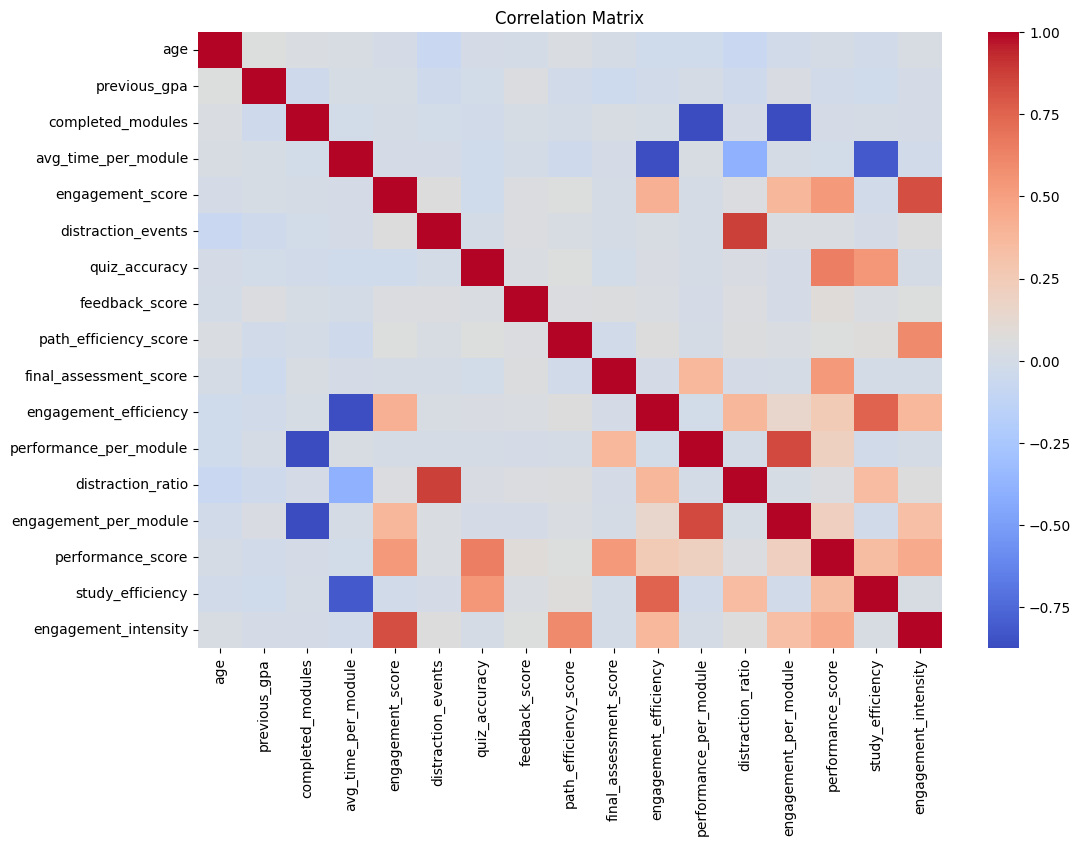

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Correlation of Numerical Features with Encoded Learning Outcome:
learning_outcome_encoded    1.000000
engagement_intensity        0.030721
engagement_per_module       0.026797
path_efficiency_score       0.024303
performance_per_module      0.023726
engagement_score            0.021568
feedback_score              0.018378
avg_time_per_module         0.016754
performance_score           0.010942
distraction_events          0.008443
final_assessment_score      0.004185
quiz_accuracy              -0.004550
distraction_ratio          -0.006823
engagement_efficiency      -0.008816
study_efficiency           -0.016149
previous_gpa               -0.028692
completed_modules          -0.031834
age                        -0.038600
Name: learning_outcome_encoded, dtype: float64


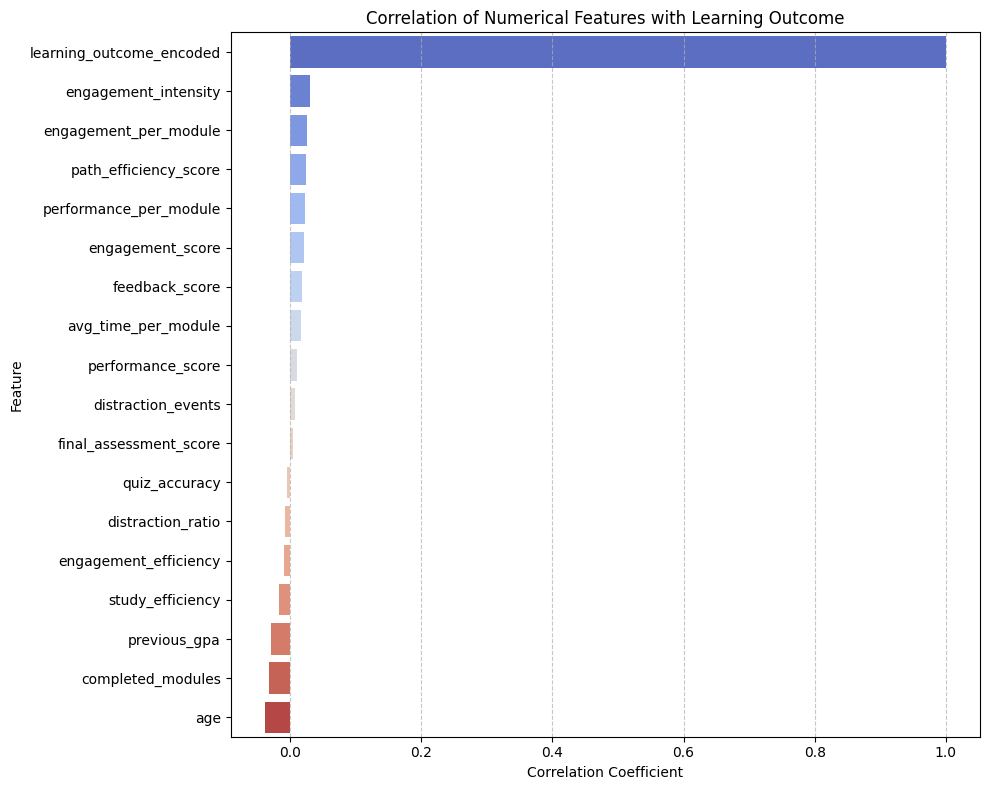

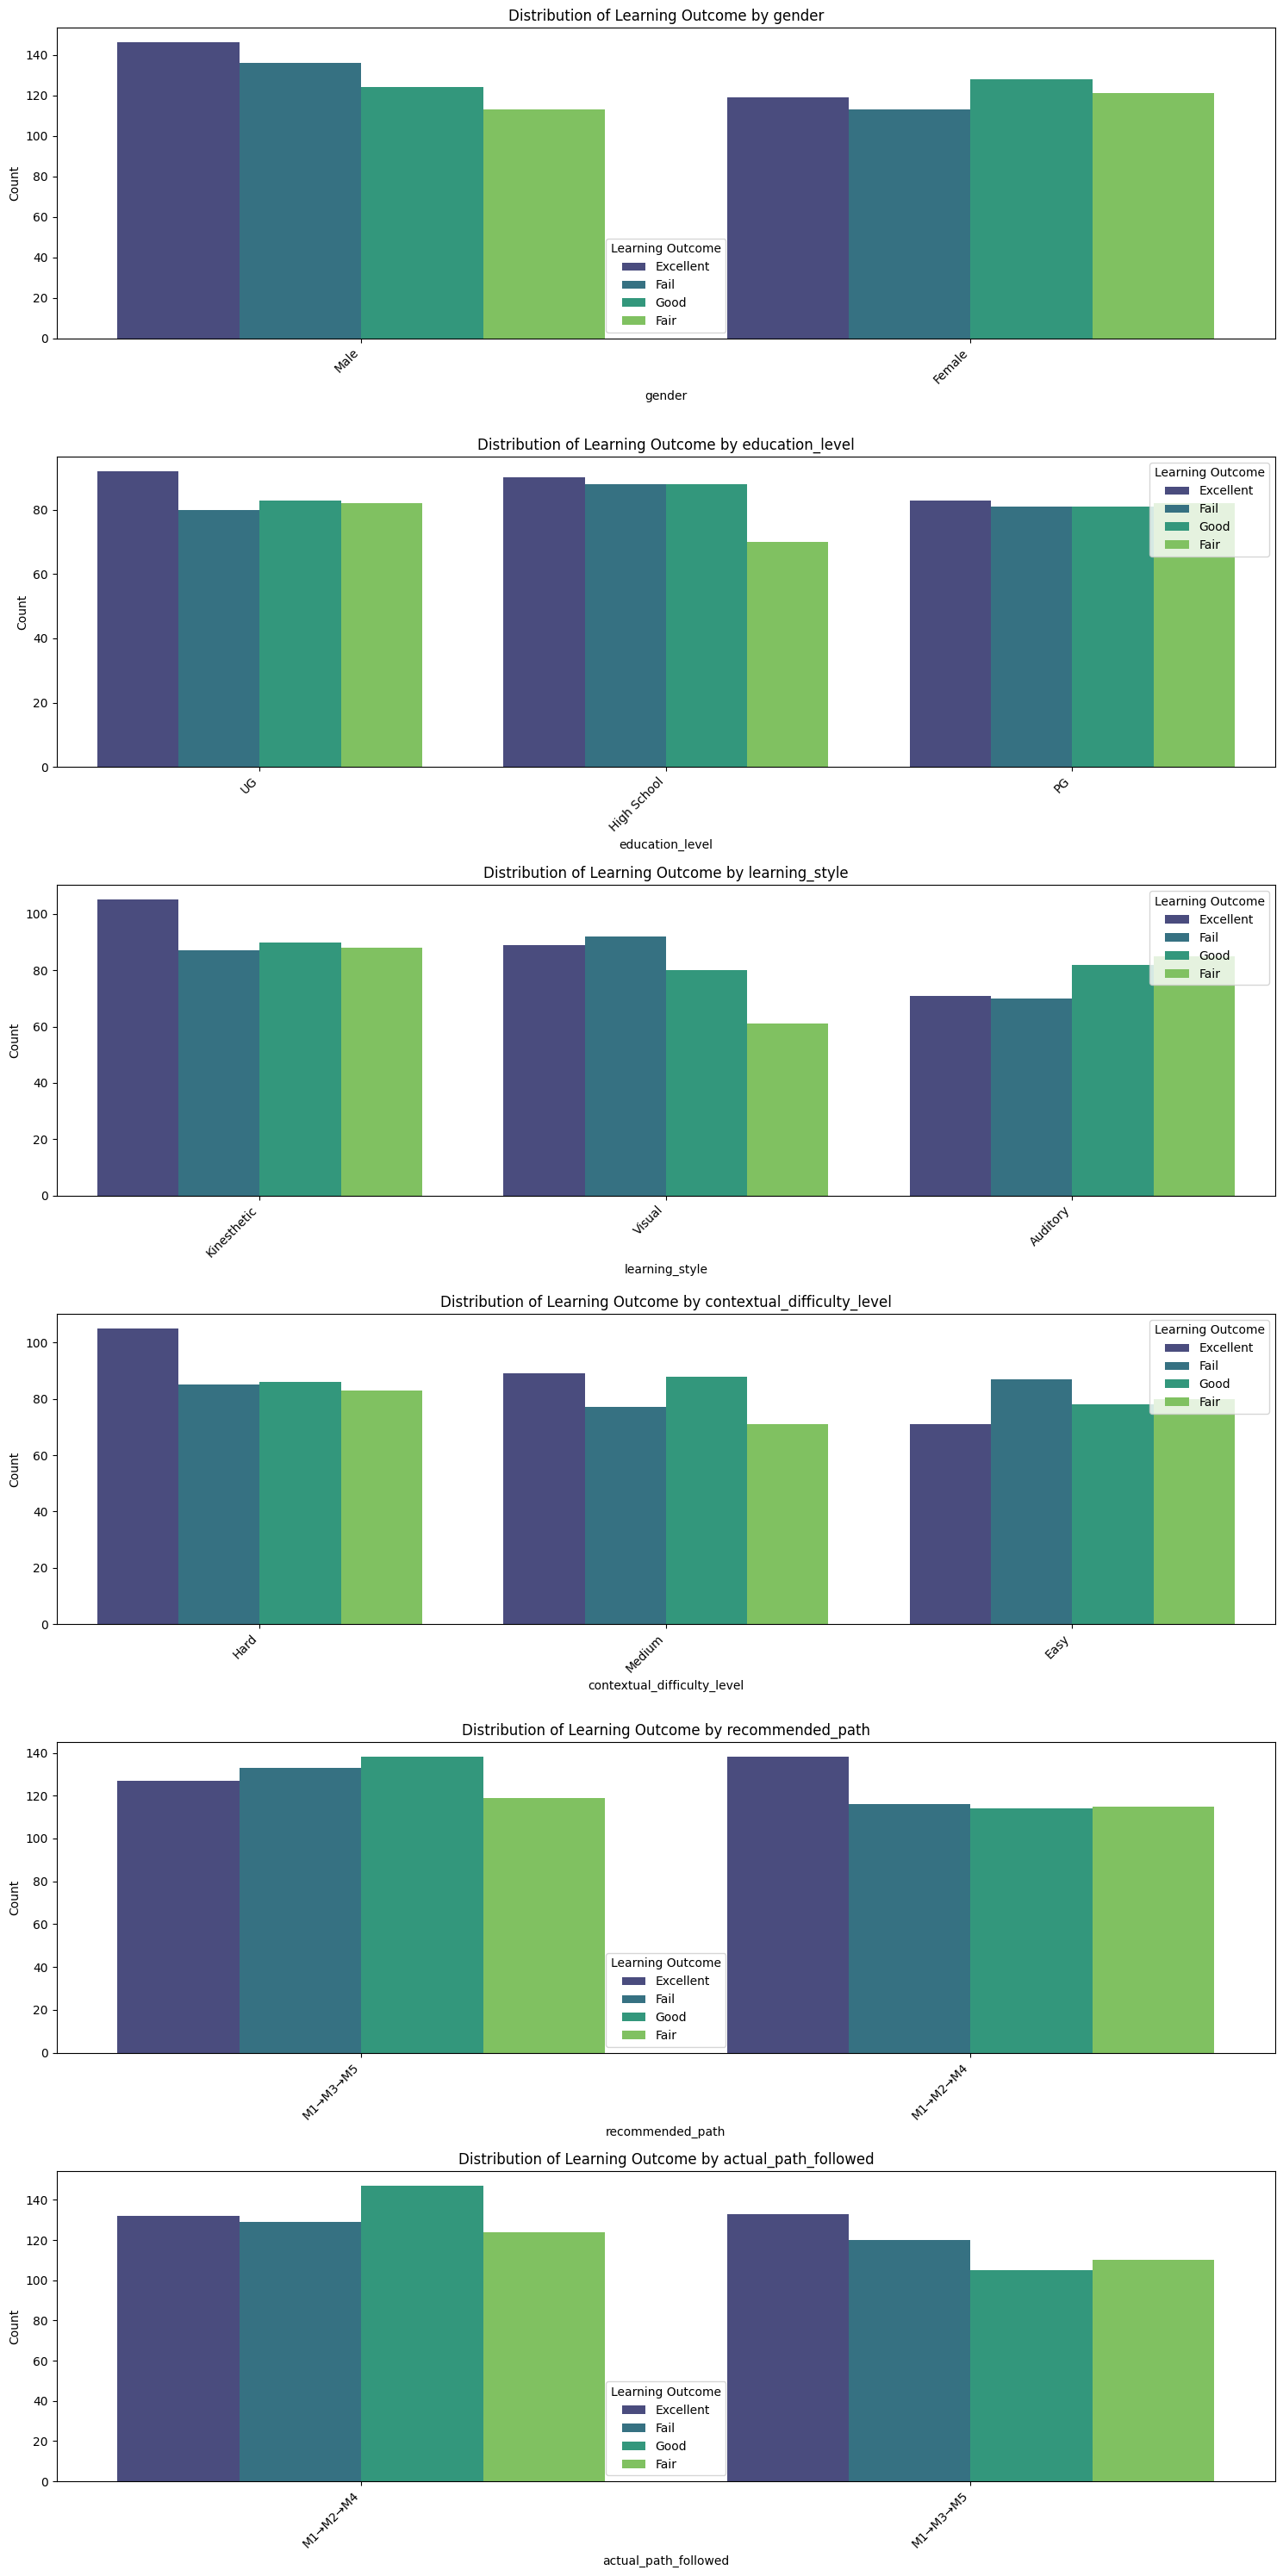

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Part 1: Numerical Features and Encoded Target Correlation ---

# Create a temporary DataFrame with all numerical columns from df
# and add the encoded 'learning_outcome' (y) to it.
# 'y' is already label-encoded from df['learning_outcome'].
df_numerical_with_target = df.select_dtypes(include=['number']).copy()
df_numerical_with_target['learning_outcome_encoded'] = y

# Calculate the correlation matrix
correlation_matrix_with_target = df_numerical_with_target.corr()

# Get correlations specifically with the encoded learning outcome
target_correlations = correlation_matrix_with_target['learning_outcome_encoded'].sort_values(ascending=False)

print("Correlation of Numerical Features with Encoded Learning Outcome:")
print(target_correlations)

# Visualize correlations with the target variable
plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlations.values, y=target_correlations.index, palette='coolwarm', hue=target_correlations.index, legend=False)
plt.title('Correlation of Numerical Features with Learning Outcome')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Part 2: Categorical Features vs. Learning Outcome ---

# Identify categorical columns from the feature set X
cat_features = X.select_dtypes(include='object').columns.tolist()

# Plotting each categorical feature against the original string 'learning_outcome' for clarity
plt.figure(figsize=(15, len(cat_features) * 5))
for i, col in enumerate(cat_features):
    plt.subplot(len(cat_features), 1, i + 1)
    sns.countplot(data=df, x=col, hue='learning_outcome', palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribution of Learning Outcome by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Learning Outcome')
plt.tight_layout()
plt.show()


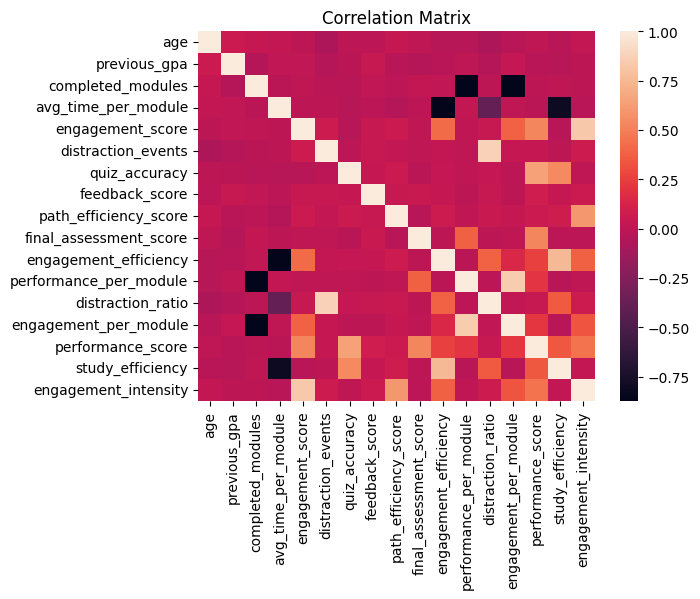

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr_matrix, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['learning_outcome_encoded'] = le.fit_transform(df['learning_outcome'])

In [29]:
corr = df.corr(numeric_only=True)

# Correlation with target
target_corr = corr['learning_outcome_encoded'].sort_values(ascending=False)

print(target_corr)

learning_outcome_encoded    1.000000
engagement_intensity        0.030721
engagement_per_module       0.026797
path_efficiency_score       0.024303
performance_per_module      0.023726
engagement_score            0.021568
feedback_score              0.018378
avg_time_per_module         0.016754
performance_score           0.010942
distraction_events          0.008443
final_assessment_score      0.004185
quiz_accuracy              -0.004550
distraction_ratio          -0.006823
engagement_efficiency      -0.008816
study_efficiency           -0.016149
previous_gpa               -0.028692
completed_modules          -0.031834
age                        -0.038600
Name: learning_outcome_encoded, dtype: float64


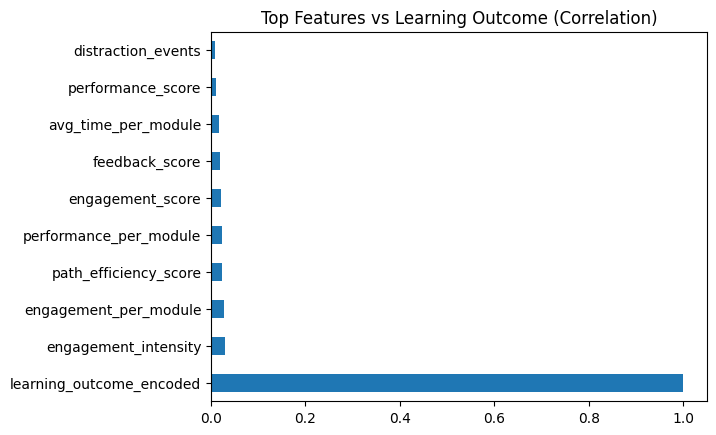

In [31]:
target_corr.head(10).plot(kind='barh')
plt.title("Top Features vs Learning Outcome (Correlation)")
plt.show()

Forcing Learnable Target

In [32]:
# =========================
# FORCE LEARNABLE TARGET
# =========================

df['performance_score'] = (
    df['quiz_accuracy'] + # Using quiz_accuracy as a proxy for quiz_avg_score
    df['final_assessment_score'] + # Using final_assessment_score as a proxy for assignment_completion_rate
    df['engagement_score']
) / 3

#df['learning_outcome'] = pd.cut(
 #   df['performance_score'],
  #  bins=[0, 50, 65, 80, 100],
   # labels=['Fail', 'Fair', 'Good', 'Excellent']
#)

# =========================
# BALANCED 4 CLASSES
# =========================

df['learning_outcome'] = pd.qcut(
    df['performance_score'],
    q=4,
    labels=['Fail', 'Fair', 'Good', 'Excellent']
)

Drop old target

In [33]:
X = df.drop(columns=['learning_outcome', 'performance_score'])
y = df['learning_outcome']

Re-encoding target

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
from sklearn.preprocessing import OrdinalEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [43]:
# Re-define categorical and numerical columns based on the current X
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

# Re-define pipelines (these should use their latest definitions)
# num_pipeline definition from cell oBIgLJqn_AZl
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# cat_pipeline definition from cell Qr6DrXe0GPhp
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Re-create the preprocessor with the updated column lists and pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.925
              precision    recall  f1-score   support

   Excellent       0.94      0.90      0.92        50
        Fail       0.92      0.96      0.94        51
        Fair       0.96      0.90      0.93        50
        Good       0.88      0.94      0.91        49

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.93       200


===== Random Forest =====
Accuracy: 0.765
              precision    recall  f1-score   support

   Excellent       0.85      0.92      0.88        50
        Fail       0.88      0.88      0.88        51
        Fair       0.65      0.66      0.65        50
        Good       0.66      0.59      0.62        49

    accuracy                           0.77       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.77      0.76       200


===== SVM =====
Accuracy: 0.81
      

Re-running after fixing classes

In [45]:
# Re-define categorical and numerical columns based on the current X
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

# Re-define pipelines (these should use their latest definitions)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Re-create the preprocessor with the updated column lists and pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.925
              precision    recall  f1-score   support

   Excellent       0.94      0.90      0.92        50
        Fail       0.92      0.96      0.94        51
        Fair       0.96      0.90      0.93        50
        Good       0.88      0.94      0.91        49

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.93       200


===== Random Forest =====
Accuracy: 0.765
              precision    recall  f1-score   support

   Excellent       0.85      0.92      0.88        50
        Fail       0.88      0.88      0.88        51
        Fair       0.65      0.66      0.65        50
        Good       0.66      0.59      0.62        49

    accuracy                           0.77       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.77      0.76       200


===== SVM =====
Accuracy: 0.81
      

In [ ]:
print(df['learning_outcome'].value_counts(dropna=False))

learning_outcome
Fail         255
Fair         252
Excellent    250
Good         243
Name: count, dtype: int64


In [ ]:
df['learning_outcome'] = pd.qcut(
    df['performance_score'].rank(method='first'),
    q=4,
    labels=['Fail', 'Fair', 'Good', 'Excellent']
)

In [ ]:
print(df['learning_outcome'].value_counts())

learning_outcome
Fail         250
Fair         250
Good         250
Excellent    250
Name: count, dtype: int64


Dropping old target

In [39]:
X = df.drop(columns=['learning_outcome', 'performance_score'])
y = df['learning_outcome']

RE-encode target

In [40]:

le = LabelEncoder()
y = le.fit_transform(y)

Re-doing split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

for name, model in models.items():
    print(f"\n===== {name} =====")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    # The error indicates that le.classes_ was an array of integers (e.g., [0, 1, 2]).
    # Based on the previous successful run, the actual string labels were 'Excellent', 'Fair', 'Good'.
    # Explicitly providing these string labels to target_names to resolve the TypeError.
    print(classification_report(y_test, y_pred, target_names=le.classes_))


===== Logistic Regression =====
Accuracy: 0.925
              precision    recall  f1-score   support

   Excellent       0.94      0.90      0.92        50
        Fail       0.92      0.96      0.94        51
        Fair       0.96      0.90      0.93        50
        Good       0.88      0.94      0.91        49

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.93       200


===== Random Forest =====
Accuracy: 0.765
              precision    recall  f1-score   support

   Excellent       0.85      0.92      0.88        50
        Fail       0.88      0.88      0.88        51
        Fair       0.65      0.66      0.65        50
        Good       0.66      0.59      0.62        49

    accuracy                           0.77       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.77      0.76       200


===== SVM =====
Accuracy: 0.81
      